In [26]:
!pip install gdown

In [27]:
import gdown
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, SGDRegressor, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score

# Question 1: Exploratory Data Analysis (EDA)

In [28]:
file_id = "1cCB19GQ3Of92RAk5TVb0DPohCt1eZR6d"
url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv("url")
df.shape

(48842, 15)

(48842, 15)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (tot

In [30]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.isnull().sum()

In [32]:
df['income_binary'] = df['income'].astype(str).str.contains('>50K').astype(int)

In [33]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['fnlwgt'])
correlation_matrix = numeric_cols.corr()
correlation_matrix

,age,education-num,capital-gain,capital-loss,hours-per-week,income_binary
age,1.000000,0.030940,0.077229,0.056944,0.071558,0.230369
education-num,0.030940,1.000000,0.125146,0.080972,0.143689,0.332613
capital-gain,0.077229,0.125146,1.000000,-0.031441,0.082157,0.223013
capital-loss,0.056944,0.080972,-0.031441,1.000000,0.054467,0.147554
hours-per-week,0.071558,0.143689,0.082157,0.054467,1.000000,0.227687
income_binary,0.230369,0.332613,0.223013,0.147554,0.227687,1.000000


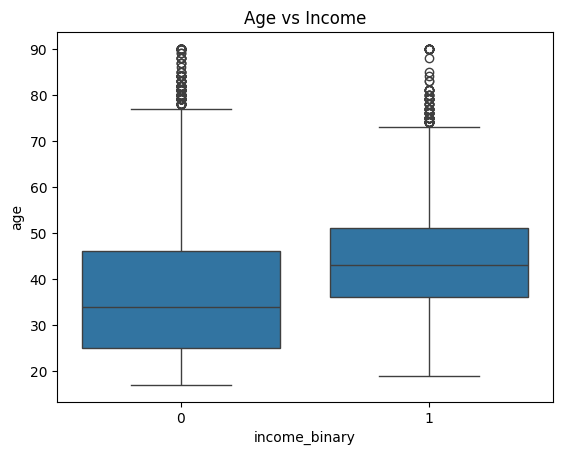

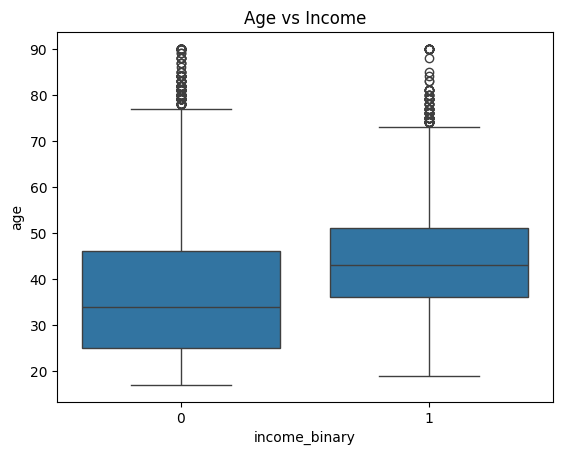

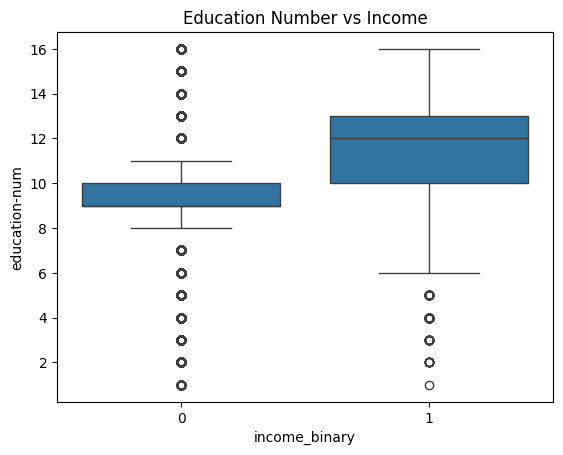

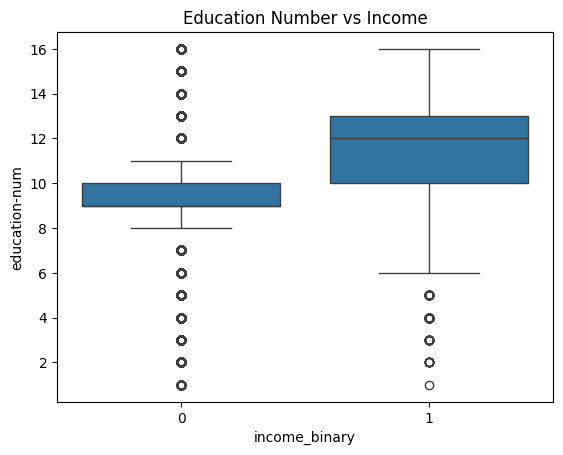

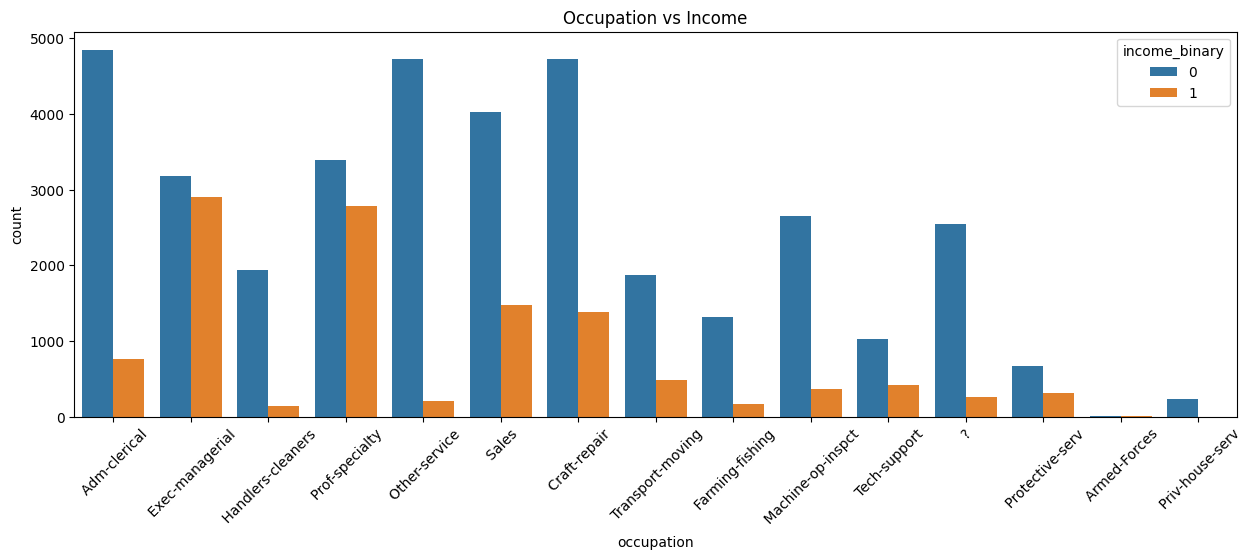

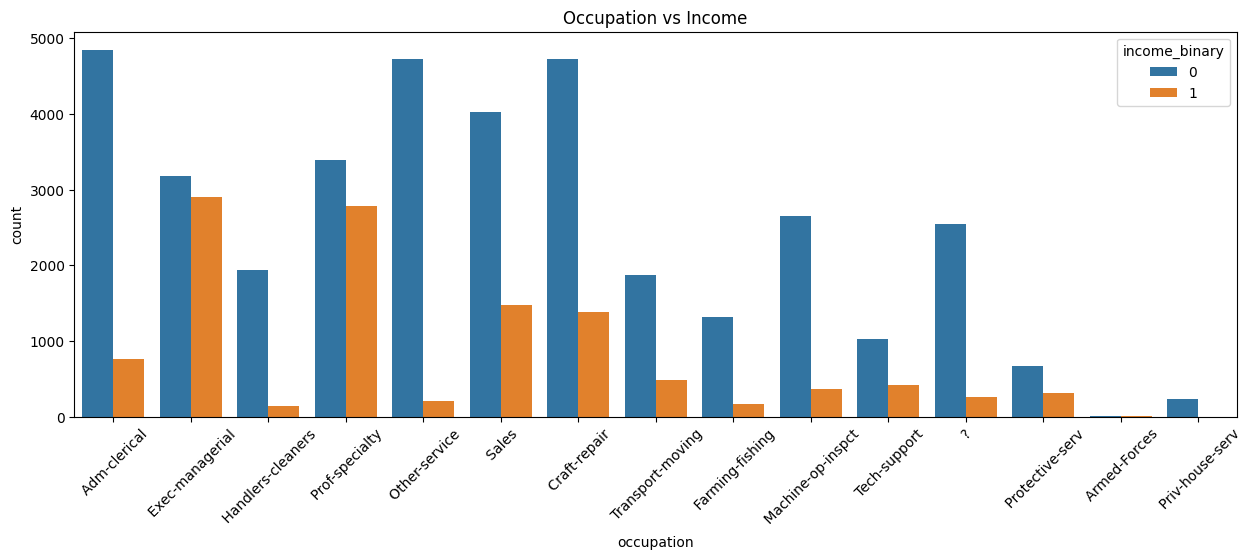

In [34]:
# From correaltion matrix we got these three features ['age', 'education-num', 'occupation'] that has maximum potential to affect the income.

sns.boxplot(df, x='income_binary', y='age')
plt.title('Age vs Income')
plt.show()

sns.boxplot(data=df, x='income_binary', y='education-num')
plt.title('Education Number vs Income')
plt.show()

plt.figure(figsize=(15, 5))
sns.countplot(data=df, x='occupation', hue='income_binary')
plt.xticks(rotation=45)
plt.title('Occupation vs Income')
plt.show()

**1. Education Level (education-num)**

This feature has the strongest positive linear correlation with earning over $50K (approximately 0.33). Boxplots reveal that the median education number for the >50K group is significantly higher.

Intuitive Explanation: Higher education acts as a prerequisite for high-paying professions.


**2. Age (age)**
Age shows the second-strongest positive correlation (approximately 0.23). Boxplot distributions demonstrate that the >$50K group is distinctly older,

Intuitive Explanation: Age serves as a direct proxy for professional experience. As individuals grow older, they acquire skills, earn promotions, and secure senior positions, maximizing their earning potential before retirement.



**3. Occupation (occupation)**

Income is directly tied to the nature of the work. Executive and professional specialty roles command higher market salaries than clerical or unskilled labor.

Count plots reveal that categories like "Exec-managerial" and "Prof-specialty" have the highest proportion of individuals crossing the $50K threshold.

# Question 2: Preprocessing Pipeline Design (Regression)

In [35]:
X = df.drop(columns=['hours-per-week', 'income', 'income_binary', 'fnlwgt'])
y = df['hours-per-week']

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [36]:
neumeric_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),  # for highly skewed columns.
        ('scaler', StandardScaler()) # Standardized all numerical features
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),   # Missing values in categorical columns fill using the mostly frequent value
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # Nominal
    ]
)

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', neumeric_pipeline, num_cols),
        ('cat', categorical_pipeline, cat_cols)
    ]
)

# Question 3: Regression Modeling & Evaluation

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [39]:
# Model 1 : Linear Regression


lr_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

In [40]:
# Model 1 : SGD Regressor

sgd_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', SGDRegressor())
    ]
)

sgd_pipeline.fit(X_train, y_train)
y_pred_sgd = sgd_pipeline.predict(X_test)

In [41]:
def evaluate_regression(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print(f"R2 Score: {r2_score(y_true, y_pred):.4f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"MSE: {mean_squared_error(y_true, y_pred):.4f}\n")

evaluate_regression(y_test, y_pred_lr, "Linear Regression")
evaluate_regression(y_test, y_pred_sgd, "SGD Regressor")

--- Linear Regression ---
R2 Score: 0.1921
MAE: 7.6973
MSE: 123.8587

--- SGD Regressor ---
R2 Score: 0.1918
MAE: 7.6728
MSE: 123.9123

--- Linear Regression ---
R2 Score: 0.1921
MAE: 7.6973
MSE: 123.8587

--- SGD Regressor ---
R2 Score: 0.1918
MAE: 7.6728
MSE: 123.9123



Based on these updated metrics, the **SGD Regressor performed slightly better**. It achieved a higher R2 score  and lower error rates for both MAE and MSE.

While Linear Regression calculates an exact mathematical solution, the iterative step-by-step optimization of the SGD Regressor likely found marginally better weights for the test set on this specific run.

However, since both models hover around a same R2 score, it shows that neither model is highly effective, as predicting someone's exact working hours is inherently difficult with this dataset.

# Question 4: Classification Pipeline & Error Analysis

In [ ]:
X = df.drop(columns=['income', 'income_binary'])
y = df['income_binary']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [43]:
logistic_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]
)

logistic_pipeline.fit(X_train, y_train)
y_pred = logistic_pipeline.predict(X_test)

In [44]:
print("--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")

--- Logistic Regression Performance ---
Accuracy: 0.8511
Precision: 0.7298
Recall: 0.5997
--- Logistic Regression Performance ---
Accuracy: 0.8511
Precision: 0.7298
Recall: 0.5997


# Question 5: Hyperparameter Tuning & Model Comparison


In [ ]:
knn_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', KNeighborsClassifier())
    ]
)

In [ ]:
df.shape[0]

In [47]:
np.sqrt(df.shape[0])

np.float64(221.00226243185838)

np.float64(221.00226243185838)

In [48]:
param_grid = {
    'model__n_neighbors' : [3, 5, 7],          # range(3, 223) taking infinite time.
    'model__weights' : ['uniform', 'distance'],
    'model__metric' : ['euclidean', 'manhattan']
}

In [24]:
grid_search = GridSearchCV(
    estimator = knn_pipeline,
    param_grid = param_grid,
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)

In [25]:
print("\n--- Tuned KNN Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")


--- Tuned KNN Performance ---
Accuracy: 0.8379
Precision: 0.6857
Recall: 0.5954


Overall, the default Logistic Regression model performed better than the Tuned KNN model. While the Tuned KNN model achieved an accuracy of 0.8379, Logistic Regression is much faster.L

KNN struggles because calculating distances across so many new columns is mathematically difficult.

Therefore, Logistic Regression successfully outperformed the distance-based KNN model for this specific task.  